# ESc1 signal EDA — training data only

All diagnostics below use the complete training portion, indexed by `msgStamp`. The final 20% of the labeled **elapsed time span** is reserved before any EDA. There is no row subsampling.

Earlier notebook versions inspected the full dataset. This split is excluded from this run and future model selection, but is not a retrospectively pristine holdout. Correlations and serial-correlation tests are descriptive, not evidence of out-of-sample predictability.

All diagnostics, full coverage and exception tables, package versions, and interpretation are kept in this notebook. Only the split boundaries are saved separately, in `splits.json` at the repository root.

In [1]:
from pathlib import Path
import json, os, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
from scipy.cluster.hierarchy import dendrogram

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'takehome').exists())
sys.path.insert(0, str(ROOT / 'src'))
from takehome.data import column_coverage, training_data
from takehome.plots import heatmap
from takehome.eda import (
    acf_matrix, autocorrelation_table, bell_shape_table, correlation_clustering,
    correlation_to_column, infer_feature_cols, monthly_shift_scores, redundant_pairs,
)

DATA_PATH = Path(os.environ.get('DATA_PATH', ROOT / 'ESc1_signal_components_5min (6).parquet'))
SCATTER_N_FEATURES = 9  # Limit displayed columns, never observations.
ACF_LAG, SEASONAL_NLAGS = 15, 288

## 0. Load, set msgStamp index, reserve the test span

Let `first` and `last` be the first and last non-null `ret_5m` timestamps. The boundary is `first + 0.8 * (last - first)`. Training is `[first, boundary)` and the reserved test block is `[boundary, last]`. This is a time split, so row percentages need not equal 80/20. Outside-span unlabeled rows are excluded; internal missing observations are retained.

In [2]:
raw = pd.read_parquet(DATA_PATH)
if raw.index.name and raw.index.name not in raw.columns:
    raw = raw.reset_index()
raw = raw.set_index('msgStamp')
if not isinstance(raw.index, pd.DatetimeIndex):
    if pd.api.types.is_numeric_dtype(raw.index.dtype):
        raise ValueError('Numeric msgStamp: specify its epoch unit explicitly before converting.')
    raw.index = pd.to_datetime(raw.index, errors='raise')
raw = raw.sort_index()
df, split = training_data(raw)
del raw  # Do not retain a full-sample frame for later cells to accidentally use.

assert df.index.name == 'msgStamp'
assert len(df) == split['train_rows'] and df.index.max() < split['cutoff']
print(split.to_string())
print(f'Training timestamps: {df.index.min()} through {df.index.max()}')
(ROOT / 'splits.json').write_text(json.dumps(split.to_dict(), default=str, indent=2))
feature_cols = infer_feature_cols(df)
price_col, cashflow_col, time_col = 'adjMid', 'cashflow', 'msgStamp'
print(f'Training shape: {df.shape}; features: {len(feature_cols)}')
display(df.head())

first_label               2014-01-02 06:05:00-05:00
cutoff                    2022-07-14 00:33:00-04:00
last_label                2024-08-30 16:55:00-04:00
train_rows                                   640734
test_rows                                    160325
train_fraction_of_time                          0.8
Training timestamps: 2014-01-02 06:05:00-05:00 through 2022-07-14 00:30:00-04:00
Training shape: (640734, 105); features: 99


,trade_date,wmid,adjMid,volume,cashflow,ret_5m,x1,x2,x3,x4,...,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99
msgStamp,,,,,,,,,,,,,,,,,,,,,
2014-01-02 06:05:00-05:00,2014-01-02,1836.844118,2008.598998,17893.0,1836.0,-0.000680,-0.000189,-0.000143,-0.000093,0.000485,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-02 06:10:00-05:00,2014-01-02,1835.672917,2007.232232,3809.0,-961.0,0.000409,-0.000308,-0.000268,-0.000200,-0.000034,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-02 06:15:00-05:00,2014-01-02,1836.407635,2008.052291,3328.0,-187.0,0.000136,-0.001099,-0.000780,-0.000550,-0.000549,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-02 06:20:00-05:00,2014-01-02,1836.811905,2008.325645,2498.0,300.0,0.000681,-0.001608,-0.001347,-0.001034,-0.000054,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-02 06:25:00-05:00,2014-01-02,1838.159786,2009.692410,2528.0,-369.0,0.000952,-0.001579,-0.001705,-0.001486,0.000182,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Per-column coverage — training data only

First and last **non-null msgStamp** for every column, non-null count, and percentage of training rows that are null. Entirely missing columns remain visible with `NaT` bounds. No test-period distribution statistics are computed.

In [3]:
coverage = column_coverage(df)
with pd.option_context('display.max_rows', None):
    display(coverage)

,first_valid,last_valid,non_null,null_pct
column,,,,
trade_date,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,640734,0.000000
wmid,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,596953,6.832945
adjMid,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,596953,6.832945
volume,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,599205,6.481473
cashflow,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,599205,6.481473
ret_5m,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,590635,7.819001
x1,2014-01-02 06:05:00-05:00,2022-07-13 16:00:00-04:00,333875,47.891793
x2,2014-01-02 06:05:00-05:00,2022-07-13 16:00:00-04:00,333875,47.891793
x3,2014-01-02 06:05:00-05:00,2022-07-13 16:00:00-04:00,333875,47.891793


## 1. Scatter matrix

Nine representative feature columns are shown for readability, using **all their training observations**. Missing pairs are omitted by the plotting routine; rows are not sampled. The all-feature correlation matrix below covers all feature pairs.

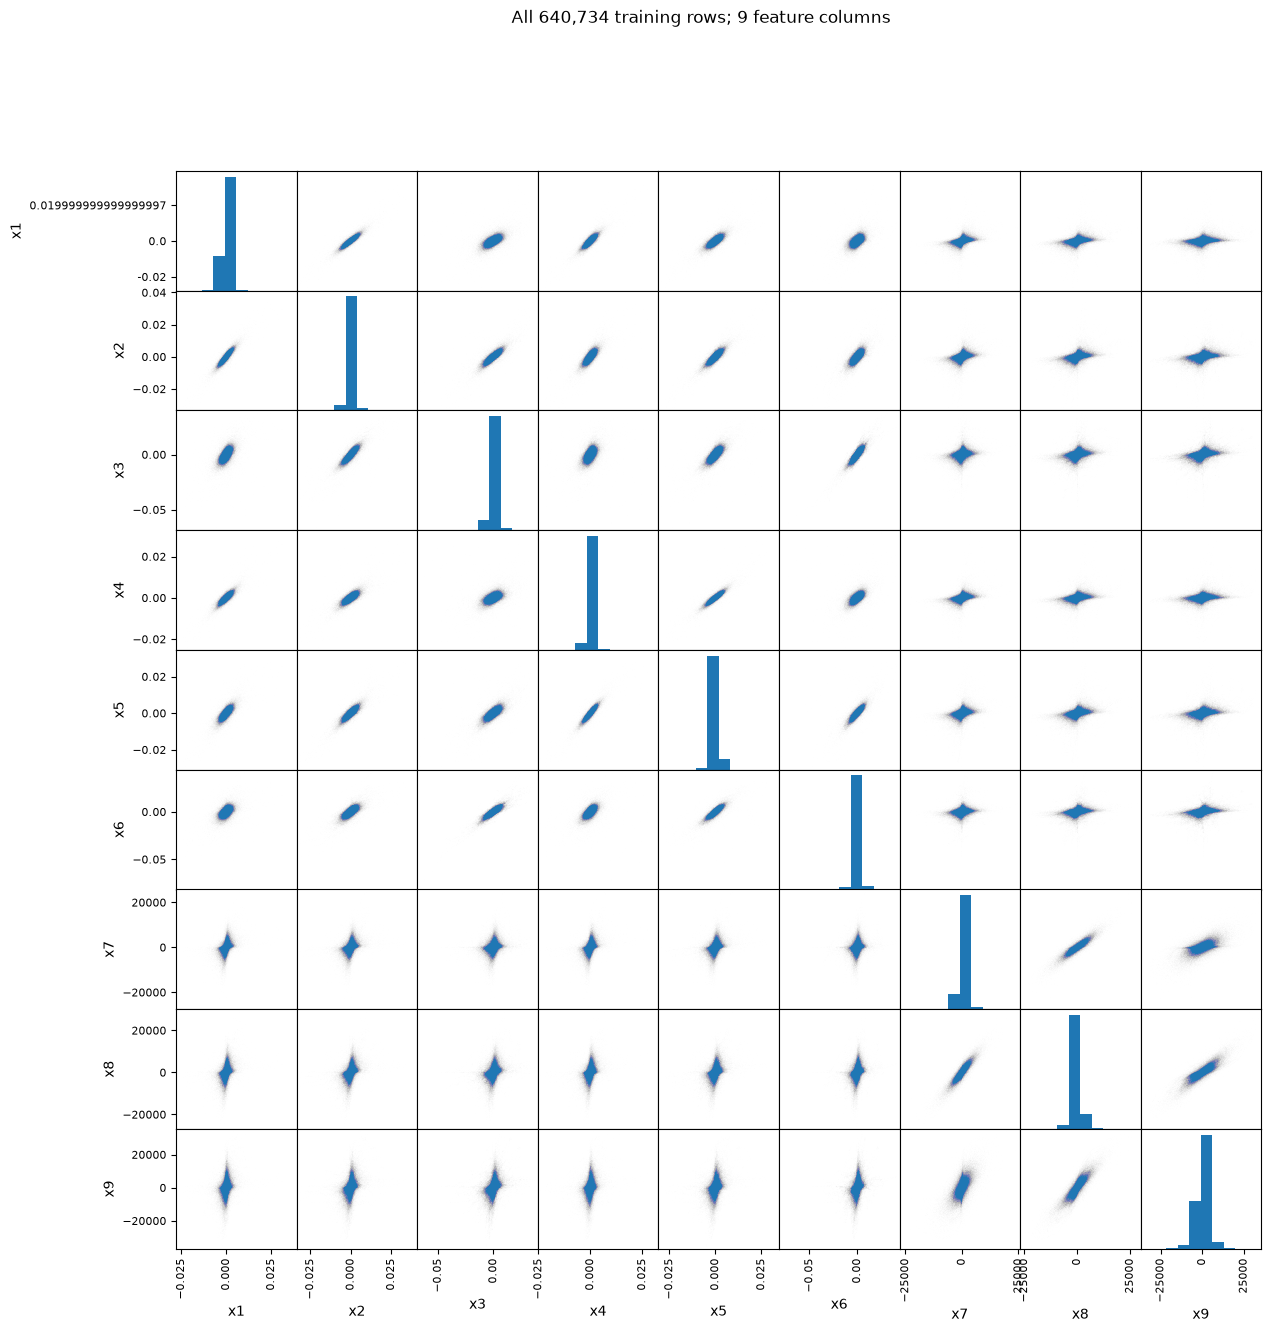

In [4]:
scatter_features = [c for c in feature_cols if df[c].nunique() > 1][:SCATTER_N_FEATURES]
scatter_matrix(df[scatter_features], figsize=(14, 14), diagonal='hist',
               alpha=.08, s=.2, rasterized=True)
plt.suptitle(f'All {len(df):,} training rows; {len(scatter_features)} feature columns', y=.995)
plt.show()
plt.close('all')

## 2. Distribution-shape screen and return sanity check

No Gaussianity test. The full-sample screen flags a dip statistic above 0.01, absolute Bowley quartile skew above 0.25, an exact point mass above 10%, or fewer than 20 unique values. These are practical degeneracy thresholds, not calibrated hypothesis tests; a pass does not prove a bell shape. High kurtosis is deliberately allowed.

Using the [Hartigan dip statistic](https://github.com/RUrlus/diptest) rather than its iid p-value avoids both a sample cap and interpreting tiny large-sample departures as useful rejections. Serially dependent features are not iid.

`adjMid.pct_change(fill_method=None)` is a contemporaneous sanity check. The supplied `ret_5m` is also reported separately; its alignment is not assumed to match that price change. All values and sample counts below are training-only.

,feature,n,nunique,max_mass,robust_skew,dip_stat,bell_like
6,x7,346261,345026,0.002940,0.065775,inf,False
68,x69,9126,9126,0.000110,-0.019220,0.002129,True
66,x67,9126,9126,0.000110,-0.012363,0.001646,True
67,x68,9126,9126,0.000110,-0.059021,0.001637,True
11,x12,16560,16560,0.000060,-0.036038,0.001600,True
...,...,...,...,...,...,...,...
56,x57,480744,480744,0.000002,-0.010753,0.000172,True
58,x59,338841,338841,0.000003,0.024714,0.000165,True
40,x41,446749,446749,0.000002,-0.029800,0.000164,True
54,x55,480744,480744,0.000002,0.037573,0.000145,True


Pass shape screen: 98/99; flagged: 1


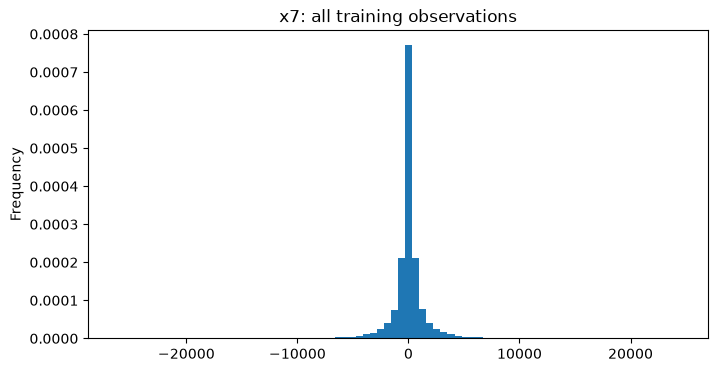

,feature,pearson,pearson_p,spearman,spearman_p,n,pearson_q,spearman_q,max_abs_corr
60,x61,0.415557,0.000000e+00,0.350083,0.000000e+00,168937,0.000000e+00,0.000000e+00,0.415557
57,x58,-0.411100,0.000000e+00,-0.337529,0.000000e+00,338832,0.000000e+00,0.000000e+00,0.411100
42,x43,0.381231,0.000000e+00,0.313393,0.000000e+00,168935,0.000000e+00,0.000000e+00,0.381231
36,x37,0.351904,0.000000e+00,0.295867,0.000000e+00,168823,0.000000e+00,0.000000e+00,0.351904
45,x46,0.345192,0.000000e+00,0.282360,0.000000e+00,99355,0.000000e+00,0.000000e+00,0.345192
33,x34,0.332063,0.000000e+00,0.264749,0.000000e+00,161112,0.000000e+00,0.000000e+00,0.332063
9,x10,0.286760,6.345562e-311,0.328594,0.000000e+00,16560,1.396024e-310,0.000000e+00,0.328594
66,x67,0.321950,4.098448e-219,0.314194,3.150248e-208,9126,7.955811e-219,6.497386e-208,0.321950
51,x52,0.319535,0.000000e+00,0.285254,0.000000e+00,167411,0.000000e+00,0.000000e+00,0.319535
18,x19,0.315361,0.000000e+00,0.261706,0.000000e+00,163843,0.000000e+00,0.000000e+00,0.315361


Top correlations to supplied ret_5m (not assumed contemporaneous):


,feature,pearson,pearson_p,spearman,spearman_p,n,pearson_q,spearman_q,max_abs_corr
57,x58,0.018288,1.831179e-26,0.025212,9.105777e-49,338777,1.812867e-24,9.014720e-47,0.025212
6,x7,-0.001722,3.108236e-01,-0.023301,8.598336e-43,346205,4.215279e-01,2.128088e-41,0.023301
9,x10,-0.007924,3.078746e-01,-0.021978,4.678876e-03,16560,4.215279e-01,8.577939e-03,0.021978
39,x40,-0.001265,3.978454e-01,-0.021057,5.449059e-45,446673,5.062010e-01,1.798190e-43,0.021057
33,x34,-0.020514,1.799257e-16,-0.016435,4.186711e-11,161114,5.937549e-15,2.590528e-10,0.020514
54,x55,-0.000528,7.141038e-01,-0.020364,2.843706e-45,480723,7.684378e-01,1.407634e-43,0.020364
12,x13,-0.003123,2.229217e-01,-0.019904,7.865186e-15,152348,3.448319e-01,7.612521e-14,0.019904
15,x16,-0.002247,3.805279e-01,-0.019792,1.111916e-14,152348,4.956877e-01,9.173306e-14,0.019792
60,x61,-0.018851,9.356760e-15,-0.018883,8.458357e-15,168885,1.852638e-13,7.612521e-14,0.018883
34,x35,-0.018762,5.022619e-14,-0.007524,2.527138e-03,161114,8.287321e-13,4.811282e-03,0.018762


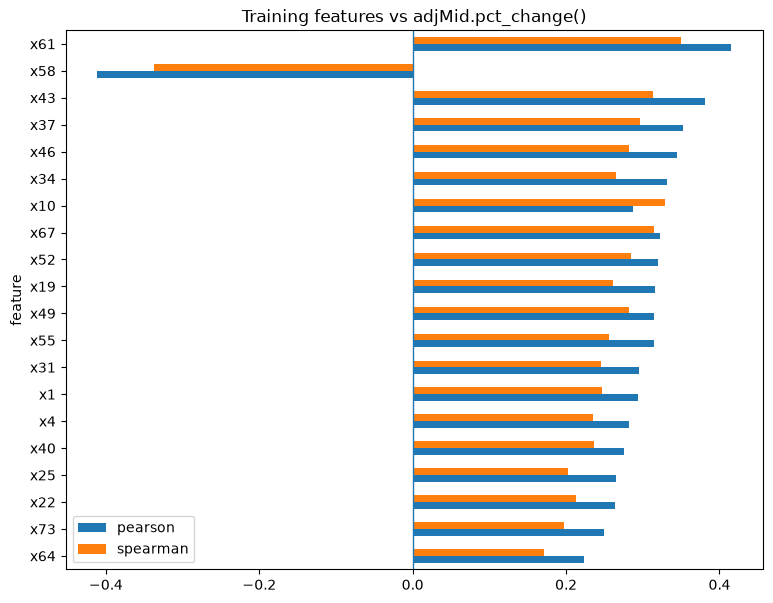

In [5]:
shape = bell_shape_table(df, feature_cols)
flagged_shape = shape.loc[~shape.bell_like]
display(shape)
print(f'Pass shape screen: {shape.bell_like.sum()}/{len(shape)}; flagged: {len(flagged_shape)}')
assert shape.set_index('feature')['n'].reindex(feature_cols).eq(df[feature_cols].count()).all()
for col in flagged_shape.feature.head(6):
    df[col].plot.hist(bins=80, density=True, figsize=(8, 4), title=f'{col}: all training observations')
    plt.show()
    plt.close('all')

df['_ret1'] = df.adjMid.pct_change(fill_method=None)
return_corr = correlation_to_column(df, '_ret1', feature_cols)
provided_corr = correlation_to_column(df, 'ret_5m', feature_cols)
strong_target = return_corr.loc[return_corr.max_abs_corr >= .10]
display(strong_target)
print('Top correlations to supplied ret_5m (not assumed contemporaneous):')
display(provided_corr.head(15))
return_corr.head(20).sort_values('max_abs_corr').plot.barh(
    x='feature', y=['pearson', 'spearman'], figsize=(9, 7),
    title='Training features vs adjMid.pct_change()')
plt.axvline(0, linewidth=1)
plt.show()
plt.close('all')

## 3. Feature correlation and dendrogram

Cluster using distance $1-|\rho_S|$ so strongly positive and strongly negative variants are grouped together. The heatmap retains signed Spearman correlation.

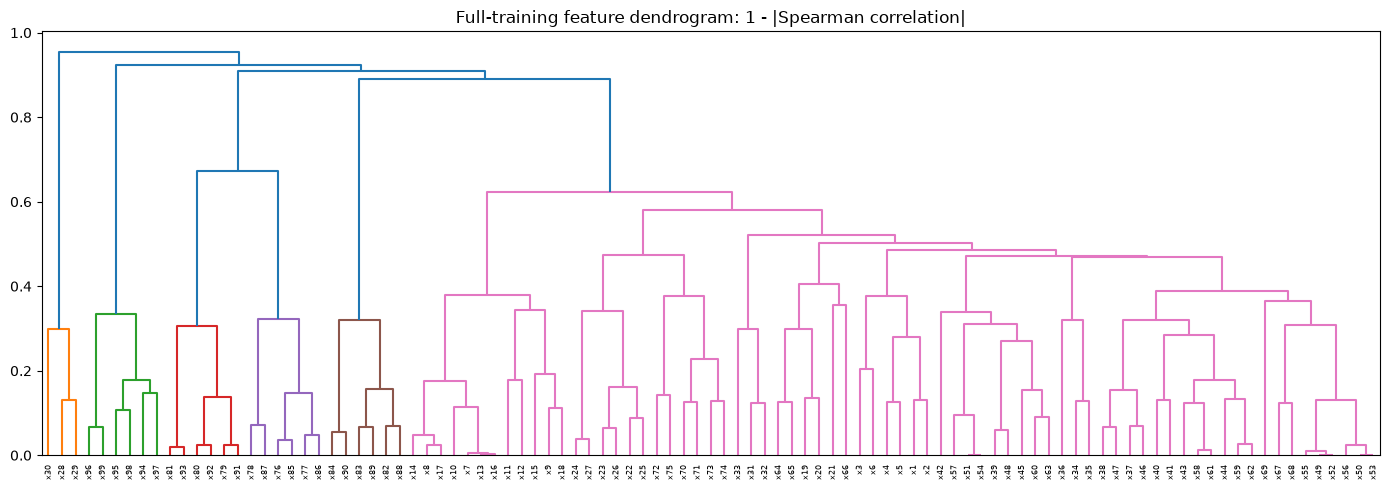

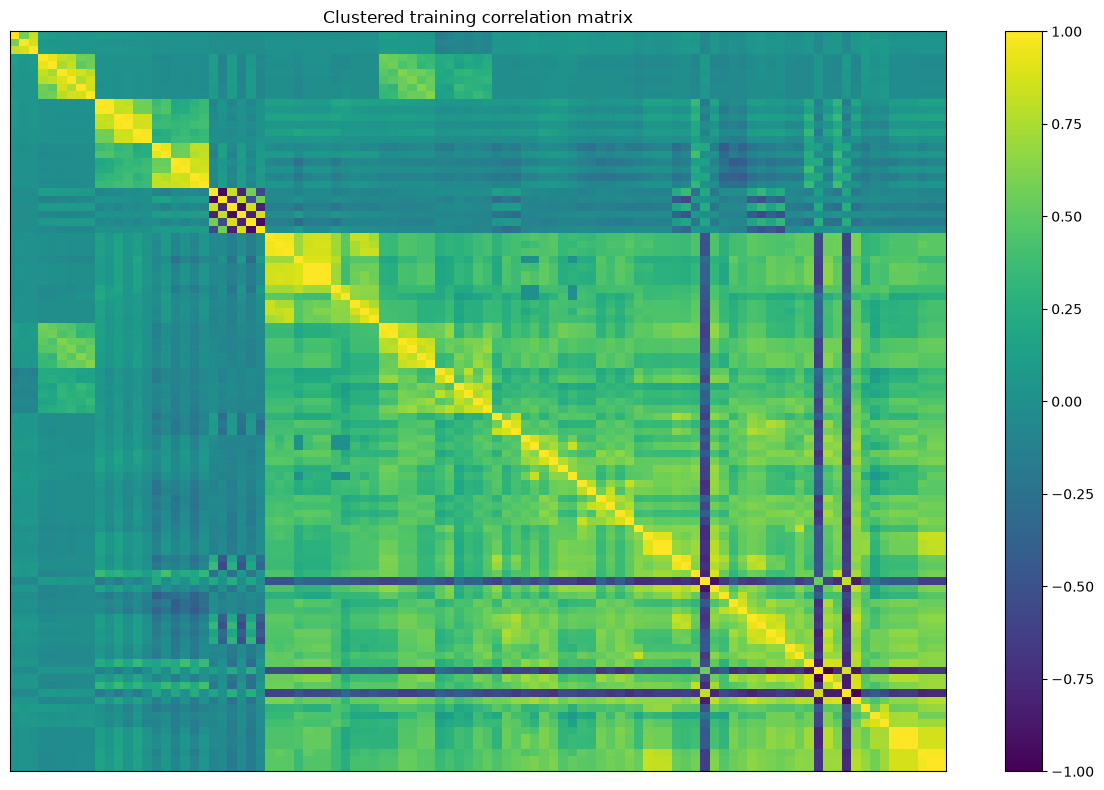

,feature1,feature2,corr,abs_corr,index_gap
0,x49,x52,0.999996,0.999996,3
1,x50,x53,0.999857,0.999857,3
2,x51,x54,0.999642,0.999642,3
3,x13,x16,0.997249,0.997249,3
4,x7,x16,0.994874,0.994874,9
5,x7,x13,0.994009,0.994009,6
6,x49,x55,0.988759,0.988759,6
7,x52,x55,0.988740,0.988740,3
8,x58,x61,-0.987044,0.987044,3
9,x81,x93,0.981349,0.981349,12


,n_pairs,median_abs_corr,p90_abs_corr,frac_gt_080
index_gap,,,,
1,98,0.818814,0.872799,0.642857
3,96,0.630711,0.941085,0.229167
2,97,0.558947,0.767274,0.072165
6,93,0.493151,0.850941,0.107527
30,69,0.482934,0.579723,0.000000
12,87,0.479111,0.719442,0.034483
9,90,0.473028,0.793256,0.100000
21,78,0.463799,0.634150,0.038462
18,81,0.459806,0.680542,0.037037


,count,mean,median
same_mod3,,,
False,3267,0.283545,0.285312
True,1584,0.344879,0.387690


In [6]:
corr, z, order = correlation_clustering(df, feature_cols, method='spearman')
plt.figure(figsize=(14, 5))
dendrogram(z, labels=feature_cols, leaf_rotation=90, leaf_font_size=6)
plt.title('Full-training feature dendrogram: 1 - |Spearman correlation|')
plt.tight_layout()
plt.show()
plt.close('all')
heatmap(corr.loc[order, order], 'Clustered training correlation matrix', labels=False, limits=(-1, 1))
plt.close('all')
upper = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
pairs = redundant_pairs(corr, threshold=.8)
display(pairs.head(30))
gap_pairs = pairs.dropna(subset=['index_gap']).copy()
gap_pairs['index_gap'] = gap_pairs.index_gap.astype(int)
all_pairs = redundant_pairs(corr, threshold=0).dropna(subset=['index_gap'])
all_pairs['index_gap'] = all_pairs.index_gap.astype(int)
gap_summary = all_pairs.groupby('index_gap').agg(
    n_pairs=('abs_corr', 'size'), median_abs_corr=('abs_corr', 'median'),
    p90_abs_corr=('abs_corr', lambda x: x.quantile(.9)),
    frac_gt_080=('abs_corr', lambda x: (x >= .8).mean()),
).sort_values('median_abs_corr', ascending=False)
all_pairs['same_mod3'] = all_pairs.index_gap.mod(3).eq(0)
mod3_summary = all_pairs.groupby('same_mod3').abs_corr.agg(['count', 'mean', 'median'])
display(gap_summary.head(20), mod3_summary)

## 4. Full-training autocorrelation

Ljung–Box(15) is applied directly to each feature, not regression residuals. Display and rank raw statistics, ACF(1), and per-feature observation counts; Q also grows with sample size. Missing values are omitted per feature: these are lags between successive observed values, not guaranteed five-minute clock intervals.

,feature,n,acf1,max_abs_acf_1_to_lag,lb_stat,lb_pvalue,lb_qvalue
56,x57,480744,0.989220,0.989220,4.578699e+06,0.0,0.0
41,x42,446749,0.989065,0.989065,4.307341e+06,0.0,0.0
65,x66,374281,0.988780,0.988780,3.650854e+06,0.0,0.0
77,x78,338776,0.990617,0.990617,3.395004e+06,0.0,0.0
5,x6,329833,0.987226,0.987226,3.214314e+06,0.0,0.0
2,x3,333875,0.987453,0.987453,3.203368e+06,0.0,0.0
59,x60,338841,0.986322,0.986322,3.135615e+06,0.0,0.0
8,x9,346261,0.976988,0.976988,2.935727e+06,0.0,0.0
55,x56,480744,0.963029,0.963029,2.612777e+06,0.0,0.0
40,x41,446749,0.963445,0.963445,2.431948e+06,0.0,0.0


Usable features: 99/99
Ljung-Box(15), FDR q<5%: 99/99


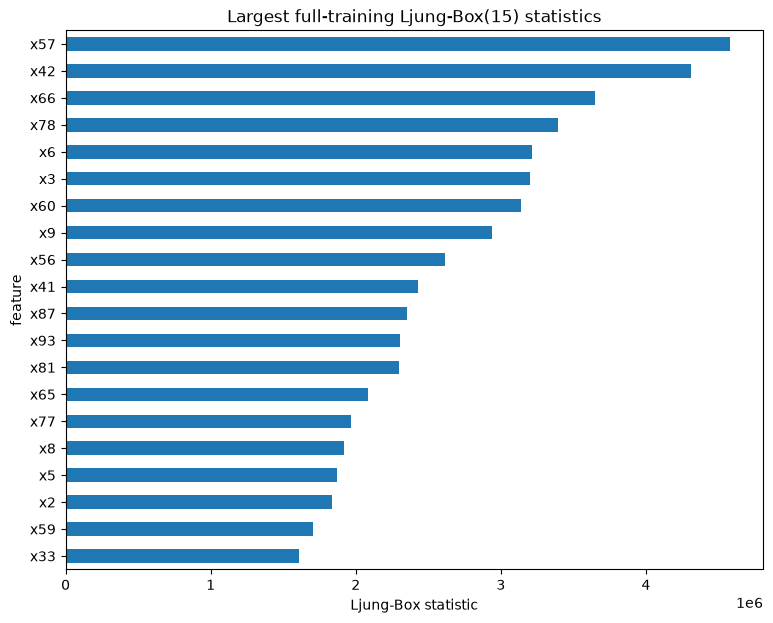

In [7]:
auto = autocorrelation_table(df, feature_cols, lag=ACF_LAG)
assert auto.set_index('feature')['n'].reindex(feature_cols).eq(df[feature_cols].count()).all()
display(auto.head(20))
print(f'Usable features: {auto.lb_stat.notna().sum()}/{len(auto)}')
print(f'Ljung-Box({ACF_LAG}), FDR q<5%: {(auto.lb_qvalue < .05).sum()}/{len(auto)}')
auto.head(20).sort_values('lb_stat').plot.barh(
    x='feature', y='lb_stat', figsize=(9, 7), legend=False,
    title=f'Largest full-training Ljung-Box({ACF_LAG}) statistics')
plt.xlabel('Ljung-Box statistic')
plt.show()
plt.close('all')

### 4.1 Longer-lag / seasonal ACF patterns

Repeated bands or peaks in the heatmap flag periodic structure. These are **row lags**: if source bars have gaps, lag 288 is not automatically a 24-hour clock-time lag.

,peak_lag,peak_acf
x30,16,0.624285
x18,16,0.618594
x78,16,0.607077
x87,16,0.605638
x33,16,0.591339
x6,16,0.591328
x84,16,0.589893
x93,16,0.589365
x66,16,0.588983
x81,16,0.585701


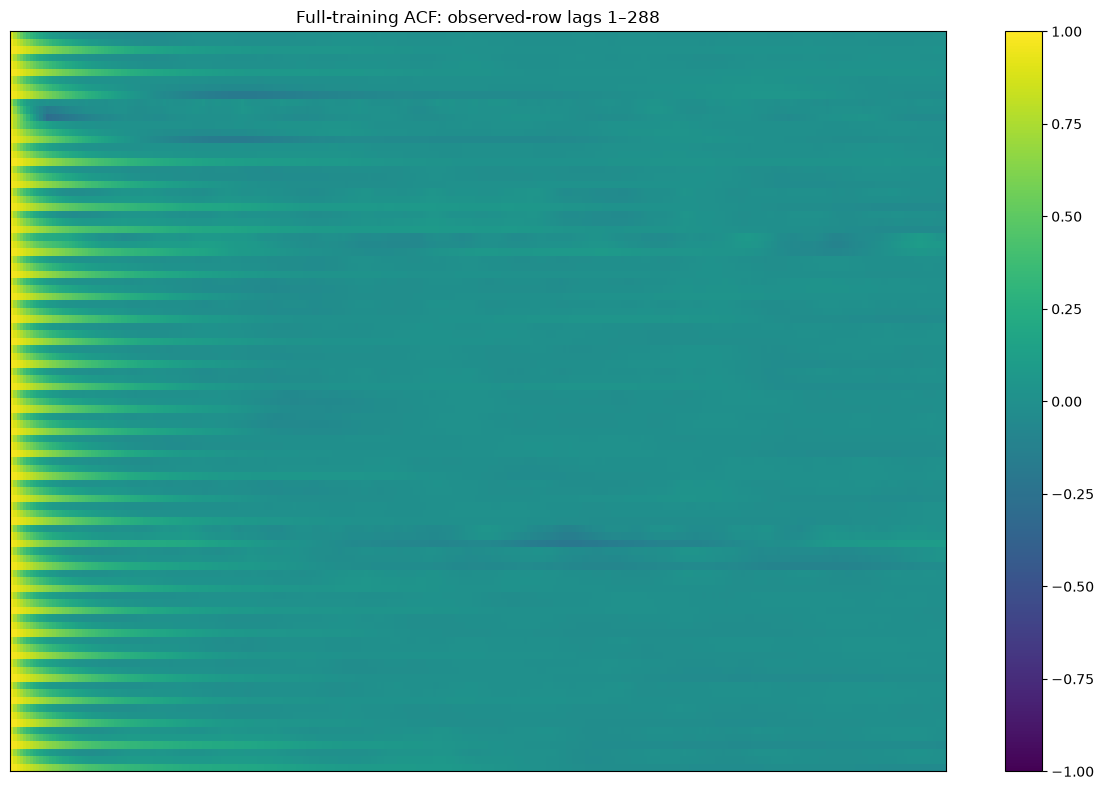

In [8]:
season_acf = acf_matrix(df, feature_cols, nlags=SEASONAL_NLAGS)
long_lag = season_acf.loc[ACF_LAG + 1:]
valid = long_lag.columns[long_lag.notna().any()]
peak_lag = long_lag[valid].abs().idxmax()
peak = pd.DataFrame({
    'peak_lag': peak_lag,
    'peak_acf': [long_lag.loc[peak_lag[c], c] for c in valid],
}).sort_values('peak_acf', key=lambda s: s.abs(), ascending=False)
display(peak.head(20))
heatmap(season_acf.loc[1:].T, 'Full-training ACF: observed-row lags 1–288', labels=False, limits=(-1, 1))
plt.close('all')

## 5. Training-period distribution shifts

Adjacent-month mean changes are scaled by the **training** standard deviation. The log standard-deviation ratio compares adjacent months. These are descriptive changes, not formal break-date estimates. All grouping now uses `msgStamp`; partial boundary months can have fewer observations.

,max_abs_monthly_mean_shift_z,max_abs_monthly_log_std_ratio
x27,1.194728,1.544659
x24,1.163821,1.561496
x99,1.127276,1.652901
x96,1.091659,1.706036
x30,1.075000,2.899247
x33,1.064781,1.325685
x39,1.005112,1.154962
x63,0.966948,1.200168
x36,0.896158,1.049421
x29,0.888844,2.891253


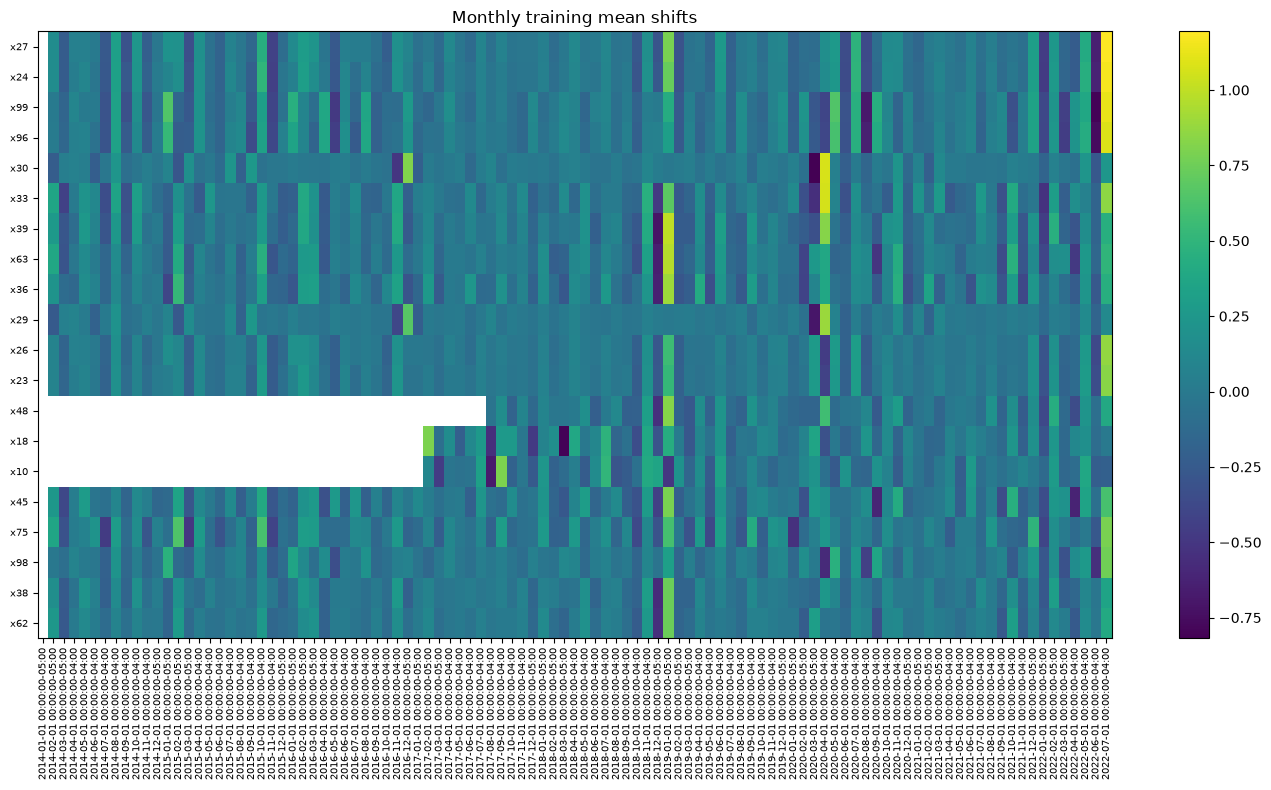

In [9]:
mean_shift, vol_shift = monthly_shift_scores(df.reset_index(), 'msgStamp', feature_cols)
breaks = pd.DataFrame({
    'max_abs_monthly_mean_shift_z': mean_shift.abs().max(),
    'max_abs_monthly_log_std_ratio': vol_shift.abs().max(),
}).sort_values('max_abs_monthly_mean_shift_z', ascending=False)
display(breaks.head(20))
heatmap(mean_shift[breaks.head(20).index].T, 'Monthly training mean shifts', figsize=(14, 8))
plt.close('all')

## 6. Cashflow: infer the definition from named fields

Only named numeric market variables are compared; `x*` features are deliberately excluded. Examine cashflow relative to volume as well as unconditional level correlations.

,wmid,adjMid,volume,cashflow,ret_5m
wmid,1.000000,0.999182,0.052109,0.008949,0.002637
adjMid,0.999182,1.000000,0.054724,0.008655,0.002669
volume,0.052109,0.054724,1.000000,-0.013539,0.008276
cashflow,0.008949,0.008655,-0.013539,1.000000,-0.016442
ret_5m,0.002637,0.002669,0.008276,-0.016442,1.000000


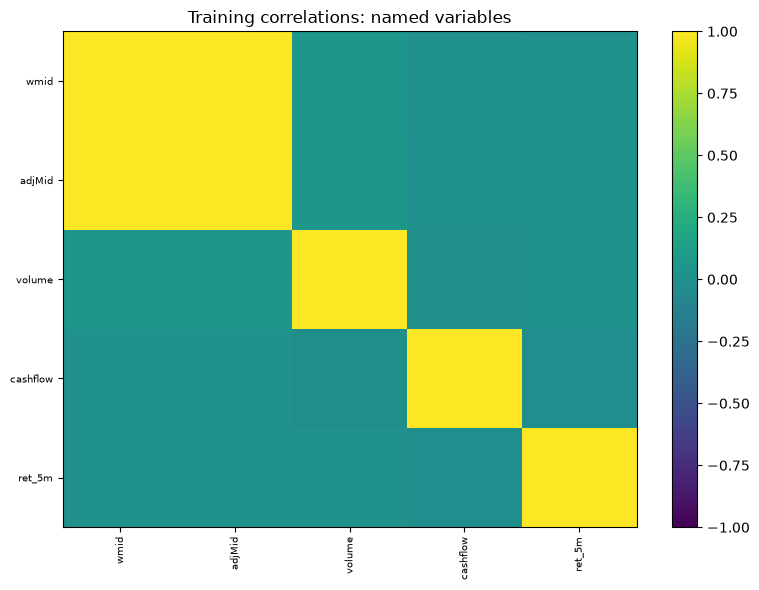

,spearman
adjMid,0.008655
wmid,0.008949
volume,-0.013539
ret_5m,-0.016442


In [10]:
named_numeric = [c for c in df.select_dtypes(include=np.number).columns
                 if c not in feature_cols and not c.startswith('_')]
named_corr = df[named_numeric].corr(method='spearman')
display(named_corr)
heatmap(named_corr, 'Training correlations: named variables', figsize=(8, 6), limits=(-1, 1))
plt.close('all')
cash_named = named_corr['cashflow'].drop('cashflow').sort_values(key=lambda x: x.abs()).to_frame('spearman')
display(cash_named)

### Cashflow-to-volume exceptions

Show rows where `abs(cashflow / volume) > 1`. Zero volume is not silently discarded: nonzero cashflow divided by zero appears as infinity and is included by this predicate. The complete named-variable exception table is displayed below, without row truncation. No CSV is exported.

In [11]:
flow_ratio = df.cashflow / df.volume
cashflow_outliers = df.loc[flow_ratio.abs().gt(1), named_numeric].assign(cashflow_per_volume=flow_ratio)
print(f'{len(cashflow_outliers):,} / {len(df):,} training rows have |cashflow / volume| > 1')
print(f'Zero-volume rows: {df.volume.eq(0).sum():,}')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(cashflow_outliers)

551 / 640,734 training rows have |cashflow / volume| > 1
Zero-volume rows: 6,471


,wmid,adjMid,volume,cashflow,ret_5m,cashflow_per_volume
msgStamp,,,,,,
2014-03-17 00:00:00-04:00,1833.603659,2012.501872,671.0,827.0,-0.000273,1.232489
2014-03-17 18:20:00-04:00,1851.981405,2032.530862,187.0,-294.0,-0.000135,-1.572193
2014-03-17 19:50:00-04:00,1852.390625,2032.805231,178.0,-247.0,-0.000270,-1.387640
2014-03-17 19:55:00-04:00,1851.705357,2032.256492,311.0,526.0,NaN,1.691318
2014-03-18 01:00:00-04:00,1852.914692,2033.353971,32.0,-51.0,0.000000,-1.593750
2014-03-18 01:10:00-04:00,1852.589286,2033.353971,33.0,-37.0,0.000135,-1.121212
2014-03-18 02:50:00-04:00,1850.055336,2030.335904,168.0,-192.0,0.000000,-1.142857
2014-03-18 19:00:00-04:00,1862.907895,2044.603129,34.0,-100.0,0.000000,-2.941176
2014-03-19 20:30:00-04:00,1851.707317,2032.256492,99.0,101.0,-0.000270,1.020202


### Volatility-scaled signed-flow diagnostic

**Working hypothesis:** cashflow is likely signed trade flow or quote imbalance, rather than an unsigned price-times-volume cash amount. This is a hypothesis, not a documented definition. Out-of-range ratios can also reflect unit, aggregation, or timestamp mismatches.

The expression below is the requested calculation. It clips the ratio to [-1, 1], scales by the previous row's EWM return standard deviation (`halflife=288*21`, pandas defaults), multiplies by the supplied return, then sums by calendar day and cumulatively. All state is learned inside training. Initial undefined volatility/contributions remain missing; pandas daily `sum()` uses its default behavior.

This curve is exploratory, not a validated strategy: the alignment of `ret_5m` with contemporaneous cashflow is unverified, and there are no execution delays or costs. Only the volatility denominator is lagged.

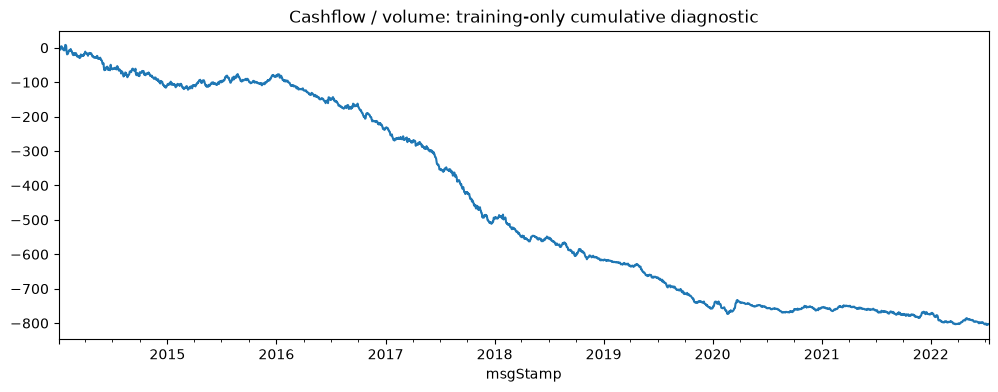

In [12]:
(df['cashflow'] / df['volume']).clip(-1, 1).div(
    df['ret_5m'].ewm(halflife=288*21).std().shift()
).mul(df['ret_5m']).resample('D').sum().cumsum().plot(
    figsize=(12, 4), title='Cashflow / volume: training-only cumulative diagnostic'
)
plt.show()
plt.close('all')

# Retain the same calculation for the summary and reproducibility checks.
flow_contribution = flow_ratio.clip(-1, 1).div(
    df.ret_5m.ewm(halflife=288*21).std().shift()
).mul(df.ret_5m)
flow_cumulative = flow_contribution.resample('D').sum().cumsum()

## Execution environment

Versions used for this evaluation are shown here, rather than exported to a separate file. The figures and statistical results above remain training-only.

In [13]:
from importlib.metadata import version
import platform

print(f'Python {platform.python_version()}')
packages = ['numpy', 'pandas', 'scipy', 'statsmodels', 'matplotlib', 'pyarrow',
            'diptest', 'nbformat', 'nbclient', 'ipykernel']
display(pd.Series({p: version(p) for p in packages}, name='version').to_frame())

Python 3.11.16


,version
numpy,2.4.6
pandas,3.0.6
scipy,1.17.1
statsmodels,0.15.0
matplotlib,3.11.2
pyarrow,25.0.1
diptest,0.11.0
nbformat,5.11.1
nbclient,0.11.0
ipykernel,7.3.0


## Training-only summary and checks

In [14]:
assert df.index.max() < split['cutoff']
assert len(df) == split['train_rows']
print('TIME-SPAN SPLIT (msgStamp)')
print(split.to_string())
print(f'Training rows actually analyzed: {len(df):,}; feature columns: {len(feature_cols)}')
print(f'Training index: {df.index.min()} through {df.index.max()}')
print('No row subsampling in plots, shape screen, correlations or ACF.')
print(f'Pass shape screen: {shape.bell_like.sum()}/{len(shape)}')
print(f'Usable Ljung-Box features: {auto.lb_stat.notna().sum()}/{len(auto)}')
print(f'Largest LB({ACF_LAG}): {auto.lb_stat.max():.1f} ({auto.iloc[0].feature})')
print(f'Strong feature pairs (|rho| >= .8): {len(pairs)}')
print(f'Cashflow/volume absolute value > 1: {len(cashflow_outliers):,} rows')
print(f'Zero-volume training rows: {df.volume.eq(0).sum():,}')
print(f'Non-null flow diagnostic contributions: {flow_contribution.count():,}')
print(f'Last cumulative flow diagnostic value: {flow_cumulative.iloc[-1]:.6g}')
print('Cashflow is likely signed trade flow or quote imbalance (hypothesis, not verified).')
print('The cashflow curve is descriptive; return alignment/executability remain unverified.')
print('\nTop contemporaneous price-return correlations')
print(return_corr[['feature', 'n', 'pearson', 'spearman']].head(10).to_string(index=False))
print('\nTop supplied ret_5m correlations')
print(provided_corr[['feature', 'n', 'pearson', 'spearman']].head(10).to_string(index=False))
print('\nLargest Ljung-Box statistics')
print(auto[['feature', 'n', 'acf1', 'lb_stat']].head(10).to_string(index=False))
print('\nStrong redundant pairs')
print(pairs.head(10).to_string(index=False))
print('\nLargest monthly shifts (training only)')
print(breaks.head(10).to_string())

TIME-SPAN SPLIT (msgStamp)
first_label               2014-01-02 06:05:00-05:00
cutoff                    2022-07-14 00:33:00-04:00
last_label                2024-08-30 16:55:00-04:00
train_rows                                   640734
test_rows                                    160325
train_fraction_of_time                          0.8
Training rows actually analyzed: 640,734; feature columns: 99
Training index: 2014-01-02 06:05:00-05:00 through 2022-07-14 00:30:00-04:00
No row subsampling in plots, shape screen, correlations or ACF.
Pass shape screen: 98/99
Usable Ljung-Box features: 99/99
Largest LB(15): 4578698.6 (x57)
Strong feature pairs (|rho| >= .8): 153
Cashflow/volume absolute value > 1: 551 rows
Zero-volume training rows: 6,471
Non-null flow diagnostic contributions: 584,302
Last cumulative flow diagnostic value: -802.578
Cashflow is likely signed trade flow or quote imbalance (hypothesis, not verified).
The cashflow curve is descriptive; return alignment/executability remai

## Last scripted execution

2026-09-28 20:55 UTC: completed 14 code cells and 10 figures in 240.8 seconds, with no cell errors.

Tables, figures, package versions and interpretation are embedded above. The only separate diagnostic file is `splits.json` at the repository root.